<h4>ML Project Life Cycle</h4>

1. Understand the Problem Statement
2. Data Collection
3. Data Checks to Perform
4. EDA
5. Data Pre Processing
6. Model Training
7. Choose Best Model


#### 1.Problem Statement

<p>The dataset is used to evaluate the performance of student (test score) based on different parameters such as Gender,Ethinicity,Parental Level of Education,Lunch etc. </p>

#### 2.Data Collection

- Dataset Source -  https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

##### 2.1 Importing Data and Libraries
1. Import Pandas,Numpy,Matplotlib,Seaborn & Warnings

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


2. Importing CSV Data and Pandas Data Frame

In [3]:
df=pd.read_csv('stud.csv')

3. Show Top 5 records

In [4]:
df.head(5)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


4. Shape of the Dataset

In [5]:
df.shape

(1000, 8)

##### 2.2 Dataset Information
- Gender - > (male,female)
- Race_Ethinicity - > ('group B', 'group C', 'group A', 'group D', 'group E')
- Parental Level of Education - > ( 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school')
- Lunch - > ('standard', 'free/reduced')
- Test_Preparation_Course - > ('none', 'completed')

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column
- Adding two columns for total and Average Score

3.1 Checking Missing Values

In [6]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

- No missing values in any of the columns

3.2 Checking for Duplicate Values

In [7]:
df.duplicated().sum()

np.int64(0)

- No duplicate values

df.duplicated.sum()

3.3 Checking for Data Types & Null Values

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


- Categorical - > [gender,race_ethinicity,parental_level_of_education,lunch,test_preparation_course]
- Numerical - > [math_score,reading_score,writing_score]

3.4 Checking for unique values for each column

In [9]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

3.5 Checking for statistics of dataset

In [10]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


- Mean for 3 numerical columns are almost same ranging from 66 to 69
- Standard Devaition are also almost same ranging from 14 to 15
- Maximum of all 3 are 100
- Minimum value for math is 0 , for reading it is 17 and for writing is 10

3.6 Checking Various Categories Present in Categorical Columns

In [11]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

In [12]:
cat_cols = list(cat_cols)
cat_cols

['gender',
 'race_ethnicity',
 'parental_level_of_education',
 'lunch',
 'test_preparation_course']

In [13]:
for i in cat_cols:
    print(i.title())
    print(f'Different Categories Present in {i} :',list(df[i].unique()))

Gender
Different Categories Present in gender : ['female', 'male']
Race_Ethnicity
Different Categories Present in race_ethnicity : ['group B', 'group C', 'group A', 'group D', 'group E']
Parental_Level_Of_Education
Different Categories Present in parental_level_of_education : ["bachelor's degree", 'some college', "master's degree", "associate's degree", 'high school', 'some high school']
Lunch
Different Categories Present in lunch : ['standard', 'free/reduced']
Test_Preparation_Course
Different Categories Present in test_preparation_course : ['none', 'completed']


3.7 Adding Columns for Total and Average Score

In [14]:
df['total'] = df['math_score'] + df['reading_score'] + df['writing_score']

In [15]:
df['average'] = df['total'] //3

In [16]:
df.head(10)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72
1,female,group C,some college,standard,completed,69,90,88,247,82
2,female,group B,master's degree,standard,none,90,95,93,278,92
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49
4,male,group C,some college,standard,none,76,78,75,229,76
5,female,group B,associate's degree,standard,none,71,83,78,232,77
6,female,group B,some college,standard,completed,88,95,92,275,91
7,male,group B,some college,free/reduced,none,40,43,39,122,40
8,male,group D,high school,free/reduced,completed,64,64,67,195,65
9,female,group B,high school,free/reduced,none,38,60,50,148,49


3.8 Count of Students with Highsest Score in each subject

In [17]:
count_math=df[df['math_score']==df['math_score'].max()]['math_score'].count()
count_reading = df[df['reading_score']==df['reading_score'].max()]['reading_score'].count()
count_writing = df[df['writing_score']==df['writing_score'].max()]['writing_score'].count()
print('No of Student with Maximum Marks in Maths:',count_math)
print('No of Student with Maximum Marks in reading:',count_reading)
print('No of Student with Maximum Marks in writing:',count_writing)


No of Student with Maximum Marks in Maths: 7
No of Student with Maximum Marks in reading: 17
No of Student with Maximum Marks in writing: 14


In [18]:
count_math=df[df['math_score'] < 50 ]['math_score'].count()
count_reading = df[df['reading_score'] < 50]['reading_score'].count()
count_writing = df[df['writing_score'] < 50]['writing_score'].count()
print('No of Student with Less than 50 Marks in Maths:',count_math)
print('No of Student with Less than 50 Marks in reading:',count_reading)
print('No of Student with Less than 50 Marks in writing:',count_writing)


No of Student with Less than 50 Marks in Maths: 135
No of Student with Less than 50 Marks in reading: 90
No of Student with Less than 50 Marks in writing: 114


- Mostly students performed bad in Maths
- Students performed well in Reading

##### 4. Exploratory Data Analysis (EDA)

4.1 Visualising Average Score and Total Score with help of KDE and Histogram

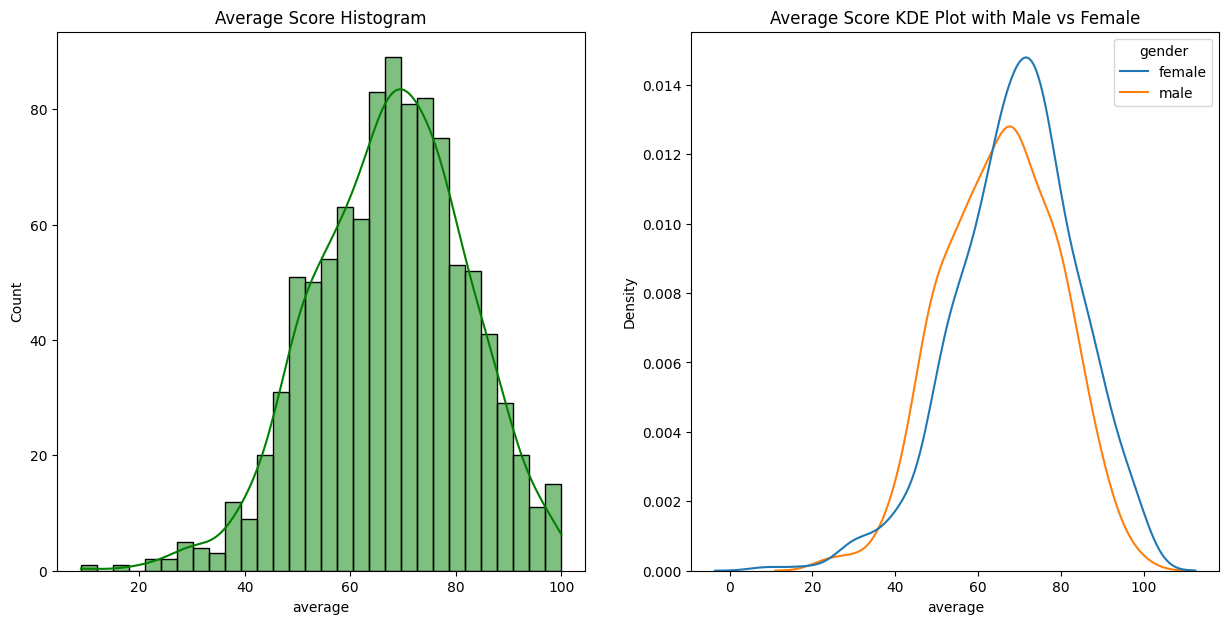

In [19]:
fig,axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
plt.title('Average Score Histogram')
sns.histplot(data=df,x='average',bins=30,color='g',kde=True)
plt.subplot(122)
plt.title('Average Score KDE Plot with Male vs Female')
sns.kdeplot(data=df,x='average',hue='gender')
plt.show()

- Most of the students have average score between 70-75
- For average marks upto 60 , males have more count  while for more than 60 females count is more

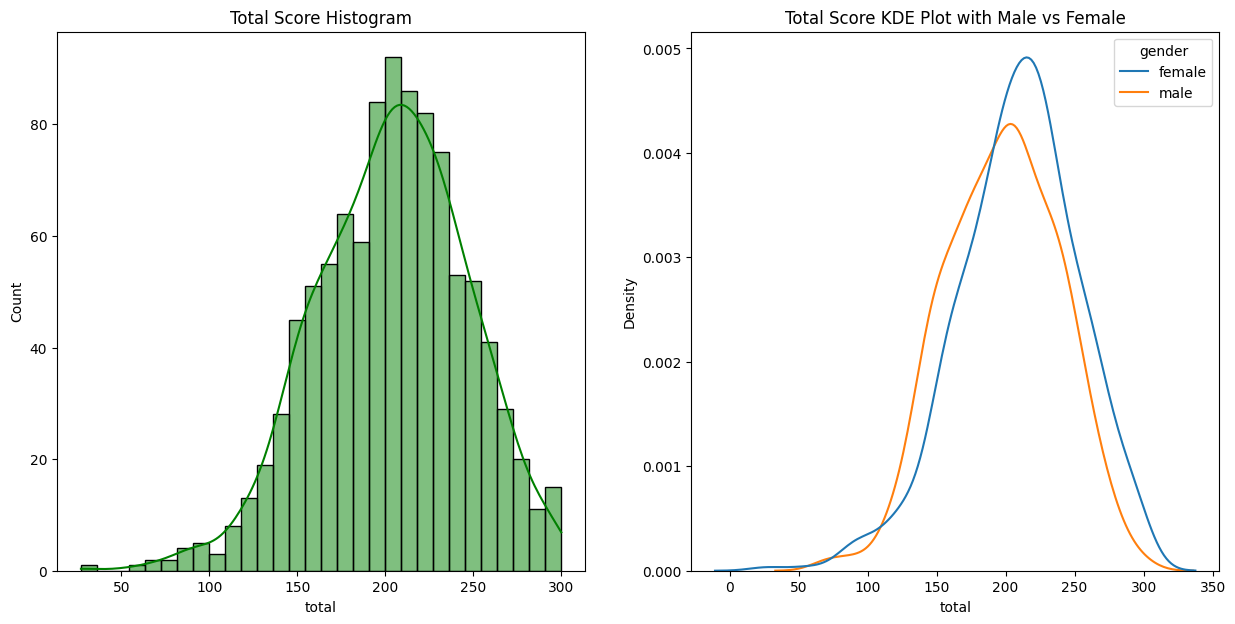

In [20]:
fig,axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
plt.title('Total Score Histogram')
sns.histplot(data=df,x='total',bins=30,color='g',kde=True)
plt.subplot(122)
plt.title('Total Score KDE Plot with Male vs Female')
sns.kdeplot(data=df,x='total',hue='gender')
plt.show()

- Most of the students have average score between 70-75
- For total marks upto 175 , males have more count  while for more than 175 females count is more

4.2 Visualising Lunch Column w.r.t to Total Score

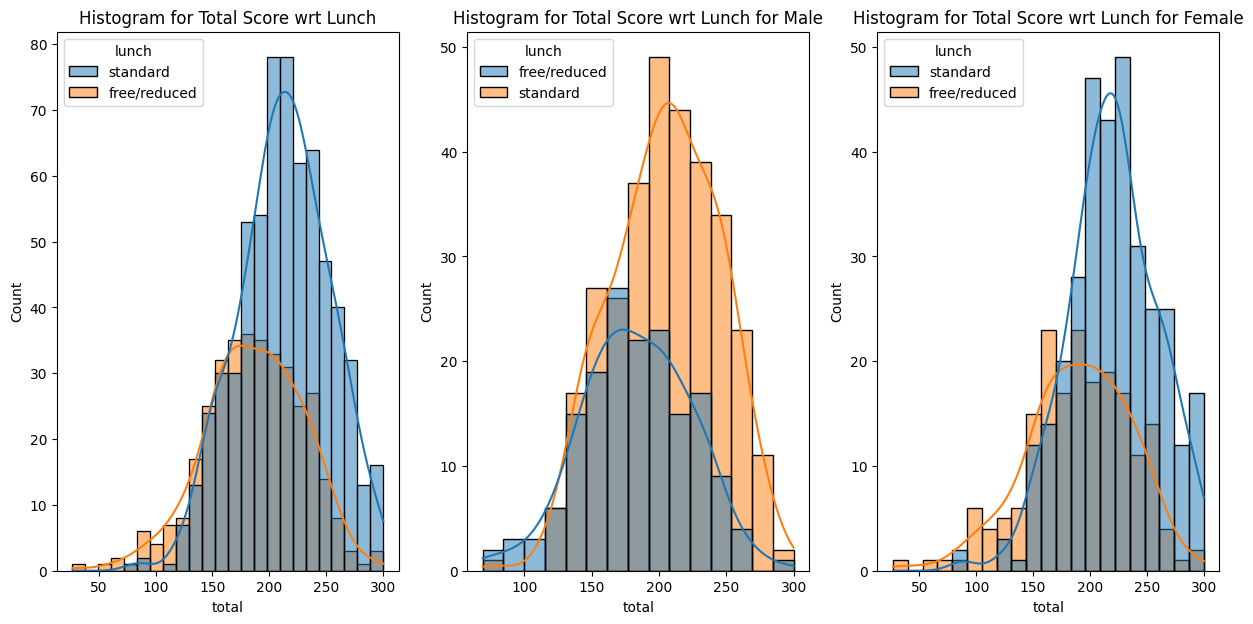

In [21]:
fig,axs = plt.subplots(1,3,figsize=(15,7))
plt.subplot(131)
plt.title('Histogram for Total Score wrt Lunch')
sns.histplot(data=df,x='total',hue='lunch',kde=True)
plt.subplot(132)
plt.title('Histogram for Total Score wrt Lunch for Male')
sns.histplot(data=df[df['gender']=='male'],x='total',hue='lunch',kde=True)
plt.subplot(133)
plt.title('Histogram for Total Score wrt Lunch for Female')
sns.histplot(data=df[df['gender']=='female'],x='total',hue='lunch',kde=True)
plt.show()



- In every band of total scores whether it low or high student prefers Standard Food over Free or Reduced Lunch
- Whether it is male or female , student prefers Standard Food over Free or Reduced Lunch

4.3 Visualising Parent Education Column w.r.t to Total Score

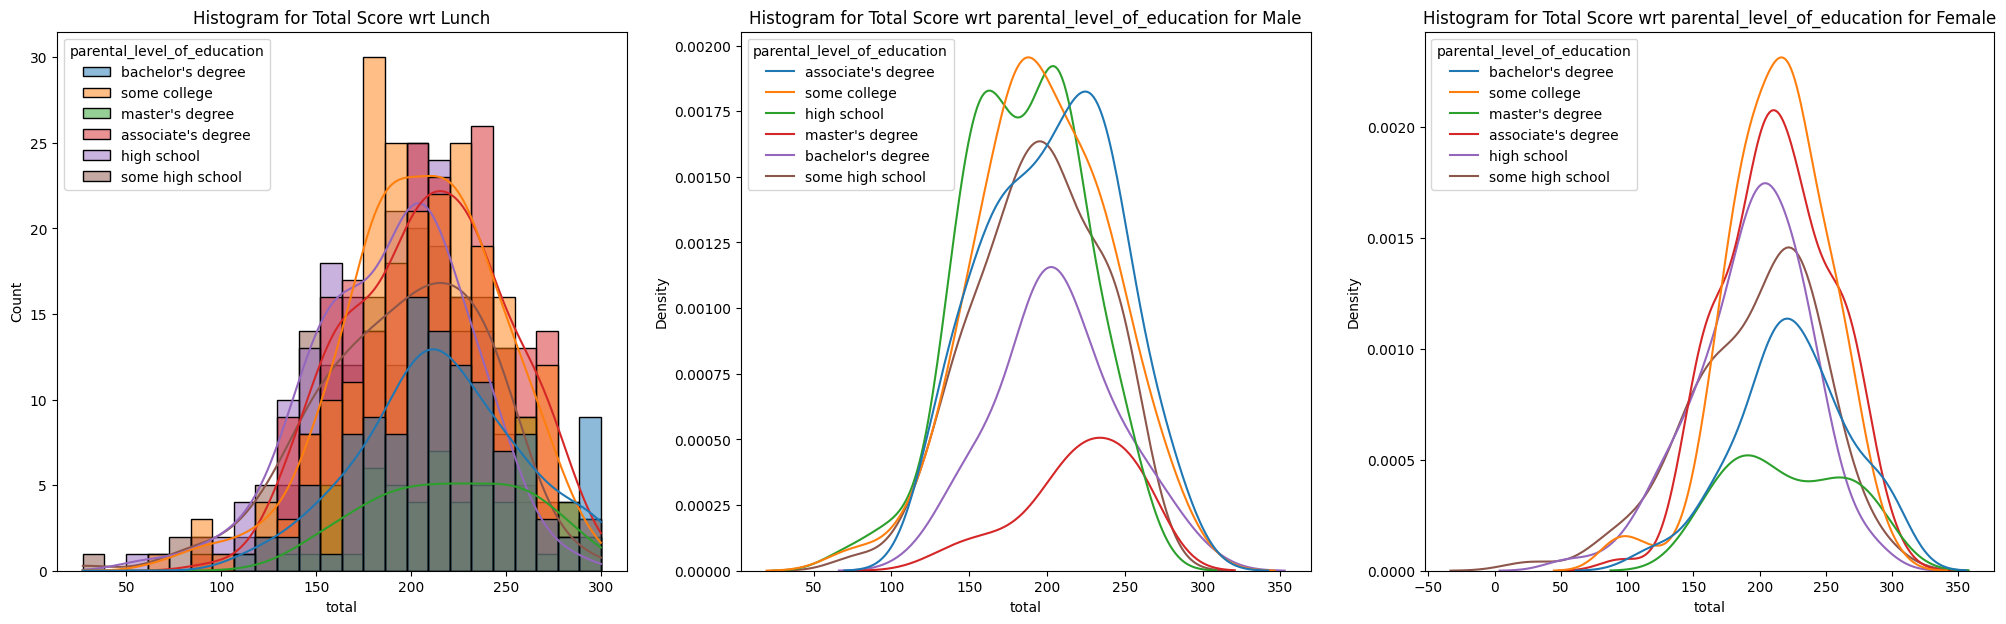

In [22]:
fig,axs = plt.subplots(1,3,figsize=(25,7))
plt.subplot(131)
plt.title('Histogram for Total Score wrt Lunch')
sns.histplot(data=df,x='total',hue='parental_level_of_education',kde=True)
plt.subplot(132)
plt.title('Histogram for Total Score wrt parental_level_of_education for Male')
sns.kdeplot(data=df[df['gender']=='male'],x='total',hue='parental_level_of_education')
plt.subplot(133)
plt.title('Histogram for Total Score wrt parental_level_of_education for Female')
sns.kdeplot(data=df[df['gender']=='female'],x='total',hue='parental_level_of_education')
plt.show()



- Most of the student's Parent have either Some College or Associate Degree

4.4 Visualising race_ethnicity wrt Total Score For Male & Female

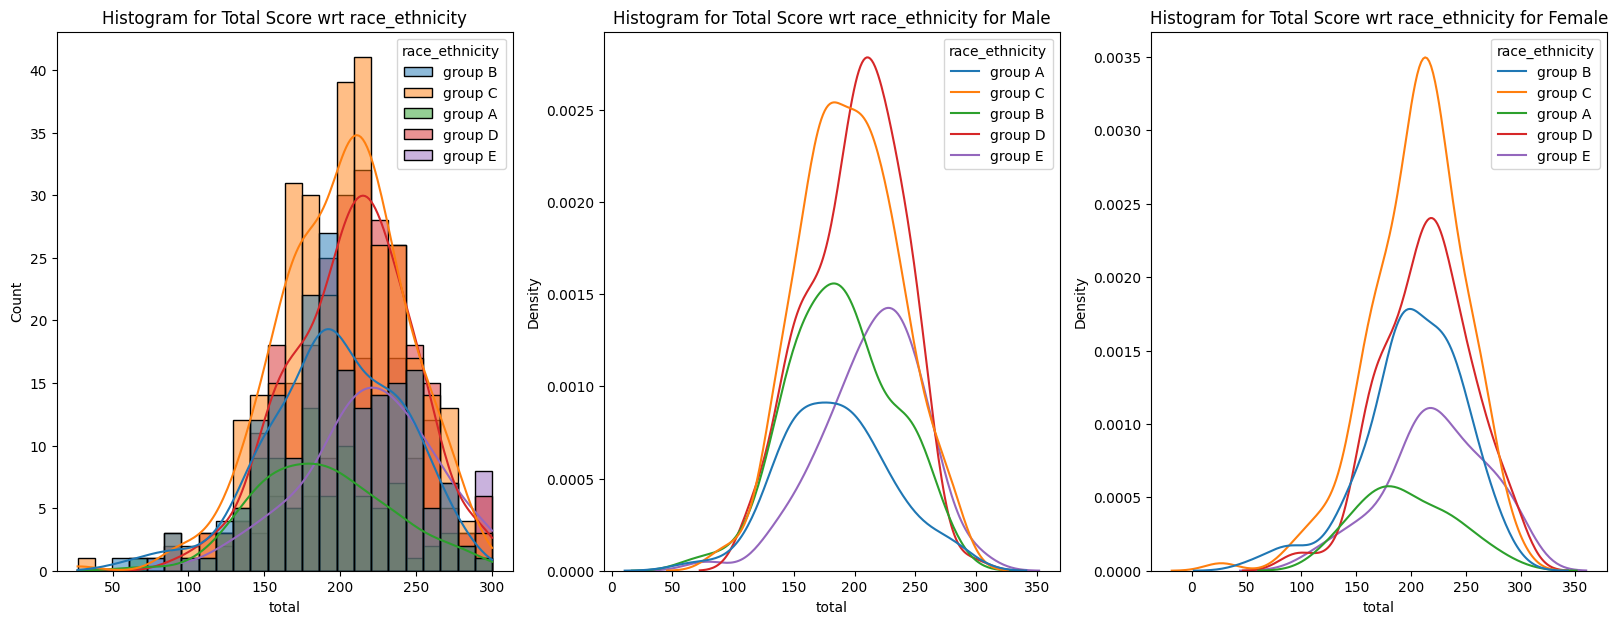

In [23]:
fig,axs = plt.subplots(1,3,figsize=(20,7))
plt.subplot(131)
plt.title('Histogram for Total Score wrt race_ethnicity')
sns.histplot(data=df,x='total',hue='race_ethnicity',kde=True)
plt.subplot(132)
plt.title('Histogram for Total Score wrt race_ethnicity for Male')
sns.kdeplot(data=df[df['gender']=='male'],x='total',hue='race_ethnicity')
plt.subplot(133)
plt.title('Histogram for Total Score wrt race_ethnicity for Female')
sns.kdeplot(data=df[df['gender']=='female'],x='total',hue='race_ethnicity')
plt.show()

- Overall Students from Group C have maximum count in all categories
- For Male Students , students from Group C and D have maximum count in all categories
- For Female Students , students from Group C have maximum count in all categories

#### Violin Plot
4.5 Maximum Score of Student in all 3 subjects

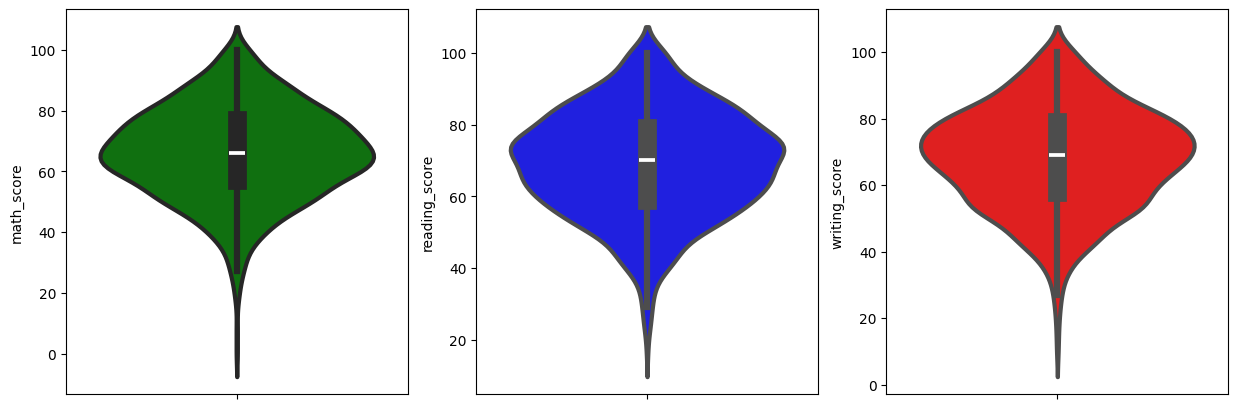

In [24]:
fig,axes = plt.subplots(1,3,figsize=(15,5))
plt.subplot(131)
sns.violinplot(data=df,y='math_score',color='green',linewidth=3)
plt.subplot(132)
sns.violinplot(data=df,y='reading_score',color='blue',linewidth=3)
plt.subplot(133)
sns.violinplot(data=df,y='writing_score',color='red',linewidth=3)
plt.show()

- The spread is large for all 3 subjects between 60-80 , maximum students scores a score between 60- 80 for all 3 subjectss

### Pie Plot

4.6 Pie Plot for all Categorical Variables

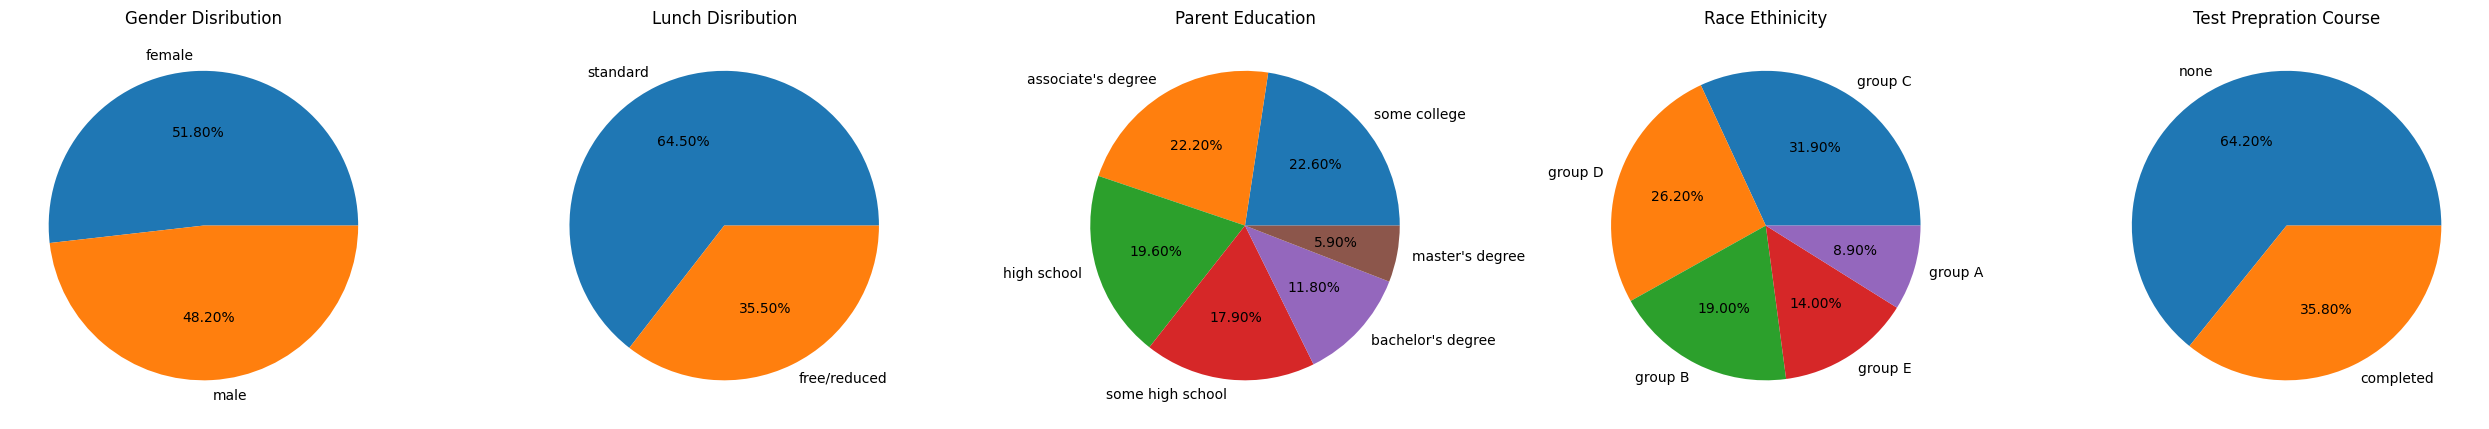

In [25]:
fig,axis = plt.subplots(1,5,figsize=(25,5))

plt.subplot(151)
plt.pie(df['gender'].value_counts(),labels=list(df['gender'].value_counts().index),autopct='%1.2f%%')
plt.title('Gender Disribution')


plt.subplot(152)
plt.pie(df['lunch'].value_counts(),labels=list(df['lunch'].value_counts().index),autopct='%1.2f%%')
plt.title('Lunch Disribution')


plt.subplot(153)
plt.pie(df['parental_level_of_education'].value_counts(),labels=list(df['parental_level_of_education'].value_counts().index),autopct='%1.2f%%')
plt.title('Parent Education')

plt.subplot(154)
plt.pie(df['race_ethnicity'].value_counts(),labels=list(df['race_ethnicity'].value_counts().index),autopct='%1.2f%%')
plt.title('Race Ethinicity')

plt.subplot(155)
plt.pie(df['test_preparation_course'].value_counts(),labels=list(df['test_preparation_course'].value_counts().index),autopct='%1.2f%%')
plt.title('Test Prepration Course')

plt.tight_layout()
plt.grid()


plt.show()


- Gender column is balanced.
- Student prefers standard lunch over free/reduced.
- Most of the parents have either associate or college degree
- 1/3rd student's belongs to Group C Race
- Almost 2/3rd students have not completed their Test Prepration Course

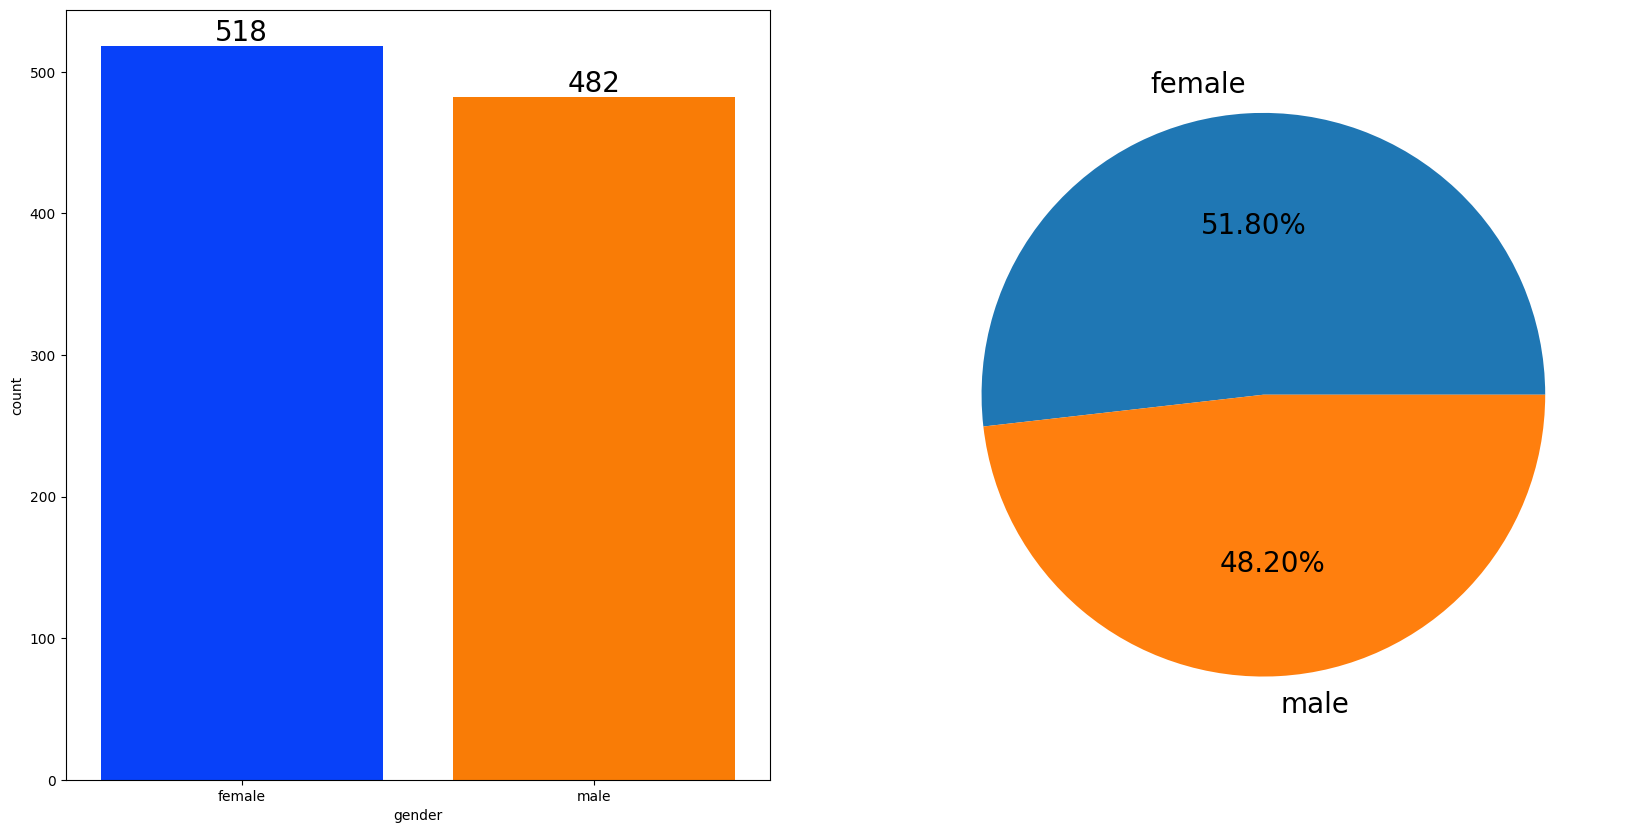

In [26]:
f,ax = plt.subplots(1,2,figsize=(20,10))
sns.countplot(x='gender',data=df,palette='bright',ax=ax[0],saturation=0.95)
for conatiner in ax[0].containers:
    ax[0].bar_label(conatiner,color='black',size=20)

plt.pie(x=df['gender'].value_counts(),labels=list(df['gender'].value_counts().index),autopct='%1.2f%%',textprops={'fontsize':20})
plt.show()


- Gender is balanced with female (52%) and male(48%)

In [27]:
gender_group = df.groupby('gender')[['math_score','writing_score','reading_score','average','total']].mean()

In [28]:
gender_group

,math_score,writing_score,reading_score,average,total
gender,,,,,
female,63.633205,72.467181,72.608108,69.239382,208.708494
male,68.728216,63.311203,65.473029,65.516598,197.512448


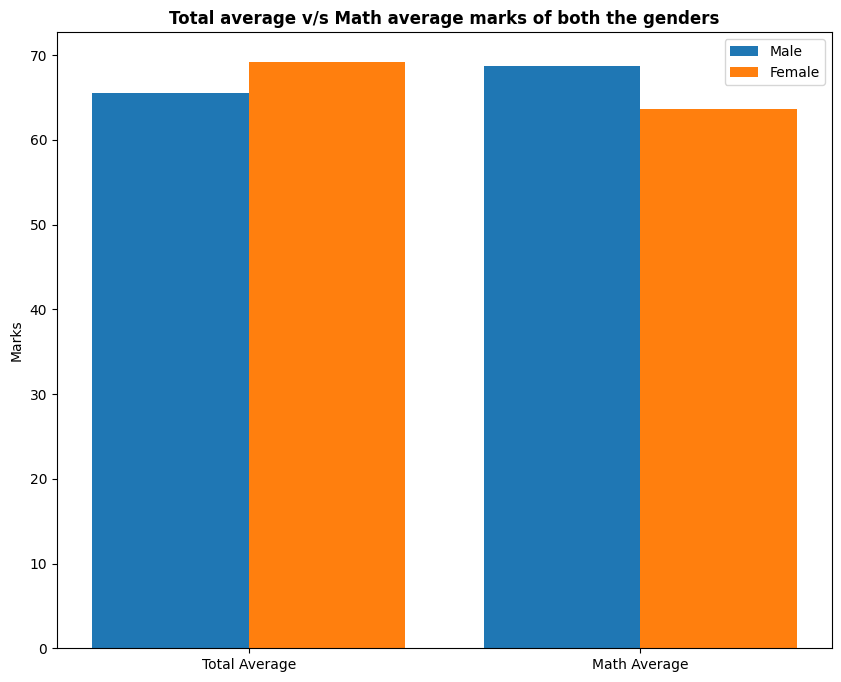

In [29]:
plt.figure(figsize=(10, 8))

X = ['Total Average','Math Average']


female_scores = [gender_group.loc['female','average'], gender_group.loc['female','math_score']]
male_scores = [gender_group.loc['male','average'], gender_group.loc['male','math_score']]

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

- Overall Female Students are performing better than male students
- For Math's subject , male students are performing better than female students

### RACE/ETHINICITY


- What is the distribution of Groups?
- Is Race/Ethinicity has any impact on student's Performance ?

#### UNIVARIATE ANALYSIS (What is the distribution of Groups?)

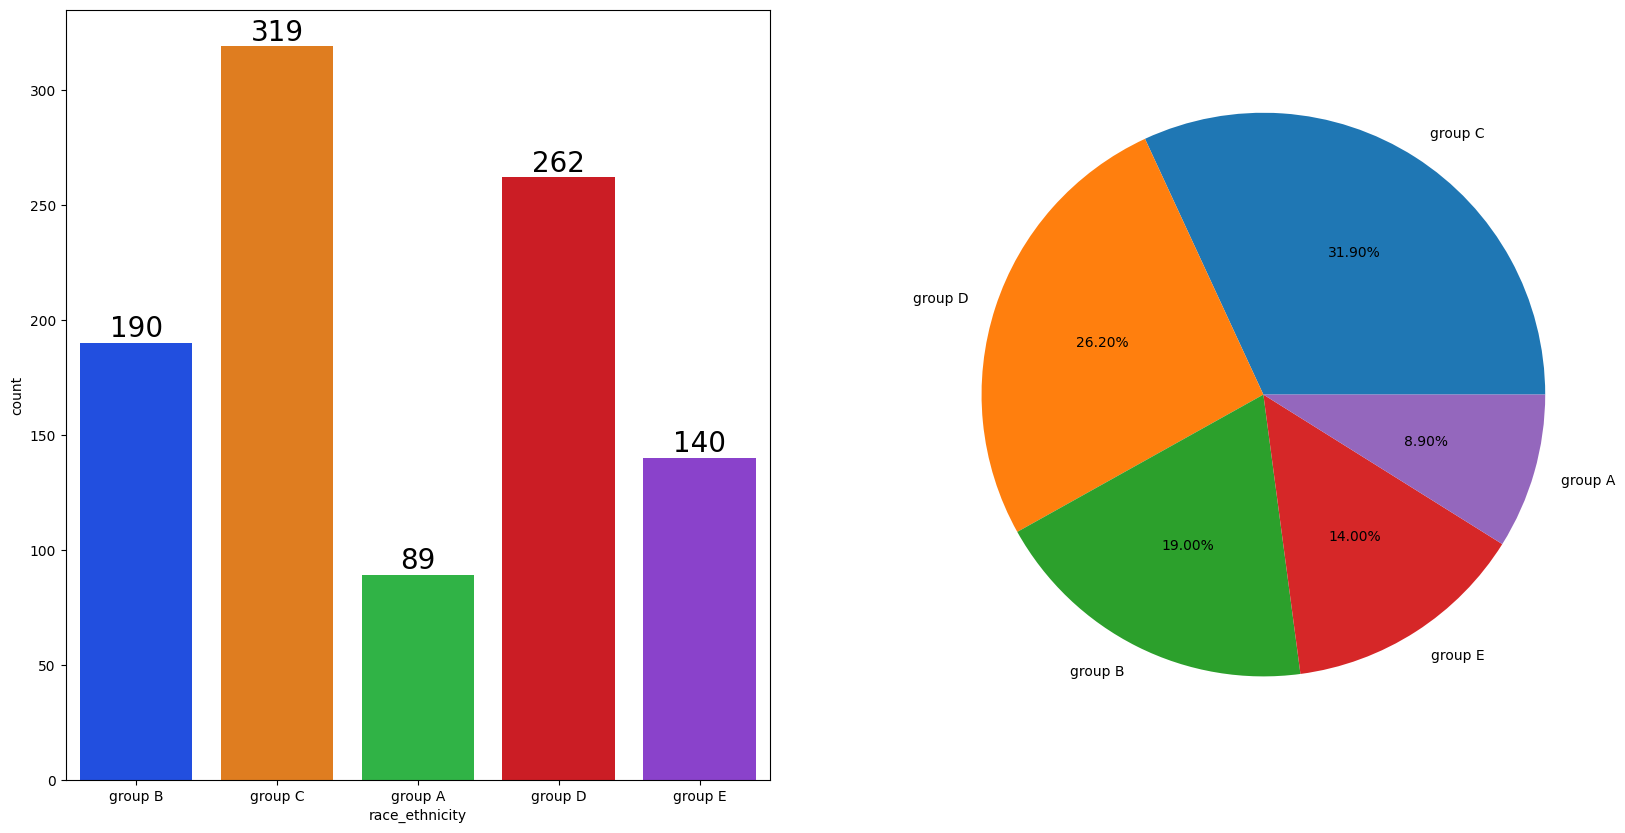

In [30]:
fig,ax = plt.subplots(1,2,figsize=(20,10))
sns.countplot(x='race_ethnicity',data=df,palette='bright',ax=ax[0])
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)

plt.pie(df['race_ethnicity'].value_counts(),labels=list(df['race_ethnicity'].value_counts().index),autopct='%1.2f%%')
plt.show()

- Most of the student belongs to Group C or Group D
- Group A has less students

In [31]:
df_race=df.groupby('race_ethnicity')[['total','reading_score','writing_score','math_score']].mean()

Text(0.5, 1.0, 'Writing Score')

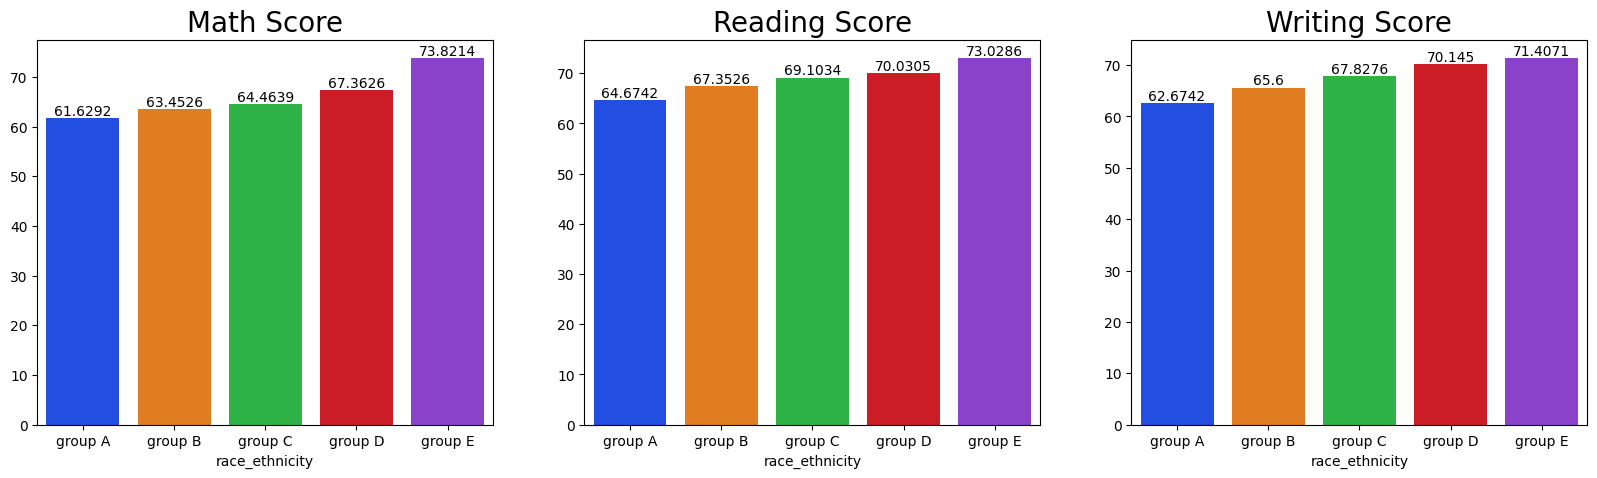

In [32]:
fig,ax=plt.subplots(1,3,figsize = (20,5))
sns.barplot(x=df_race['math_score'].index,y=df_race['math_score'].values,ax=ax[0],palette='bright')
for container in ax[0].containers:
    ax[0].bar_label(container,size=10,color='black')
ax[0].set_title('Math Score',color='black',size=20)

sns.barplot(x=df_race['reading_score'].index,y=df_race['reading_score'].values,ax=ax[1],palette='bright')
for container in ax[1].containers:
    ax[1].bar_label(container,size=10,color='black')
ax[1].set_title('Reading Score',color='black',size=20)

sns.barplot(x=df_race['writing_score'].index,y=df_race['writing_score'].values,ax=ax[2],palette='bright')
for container in ax[2].containers:
    ax[2].bar_label(container,size=10,color='black')
ax[2].set_title('Writing Score',color='black',size=20)

- Students of Group E are performing best in every subject
- Students of Group A are performing poor in every subject

#### PARENTAL LEVEL OF EDUCATION

- What is the distribution of Parent Level of Education
- Is Parent Level of Education has any impact on Student Performance

#### Univariate Analysis (Distribution of Parent Level of Education)

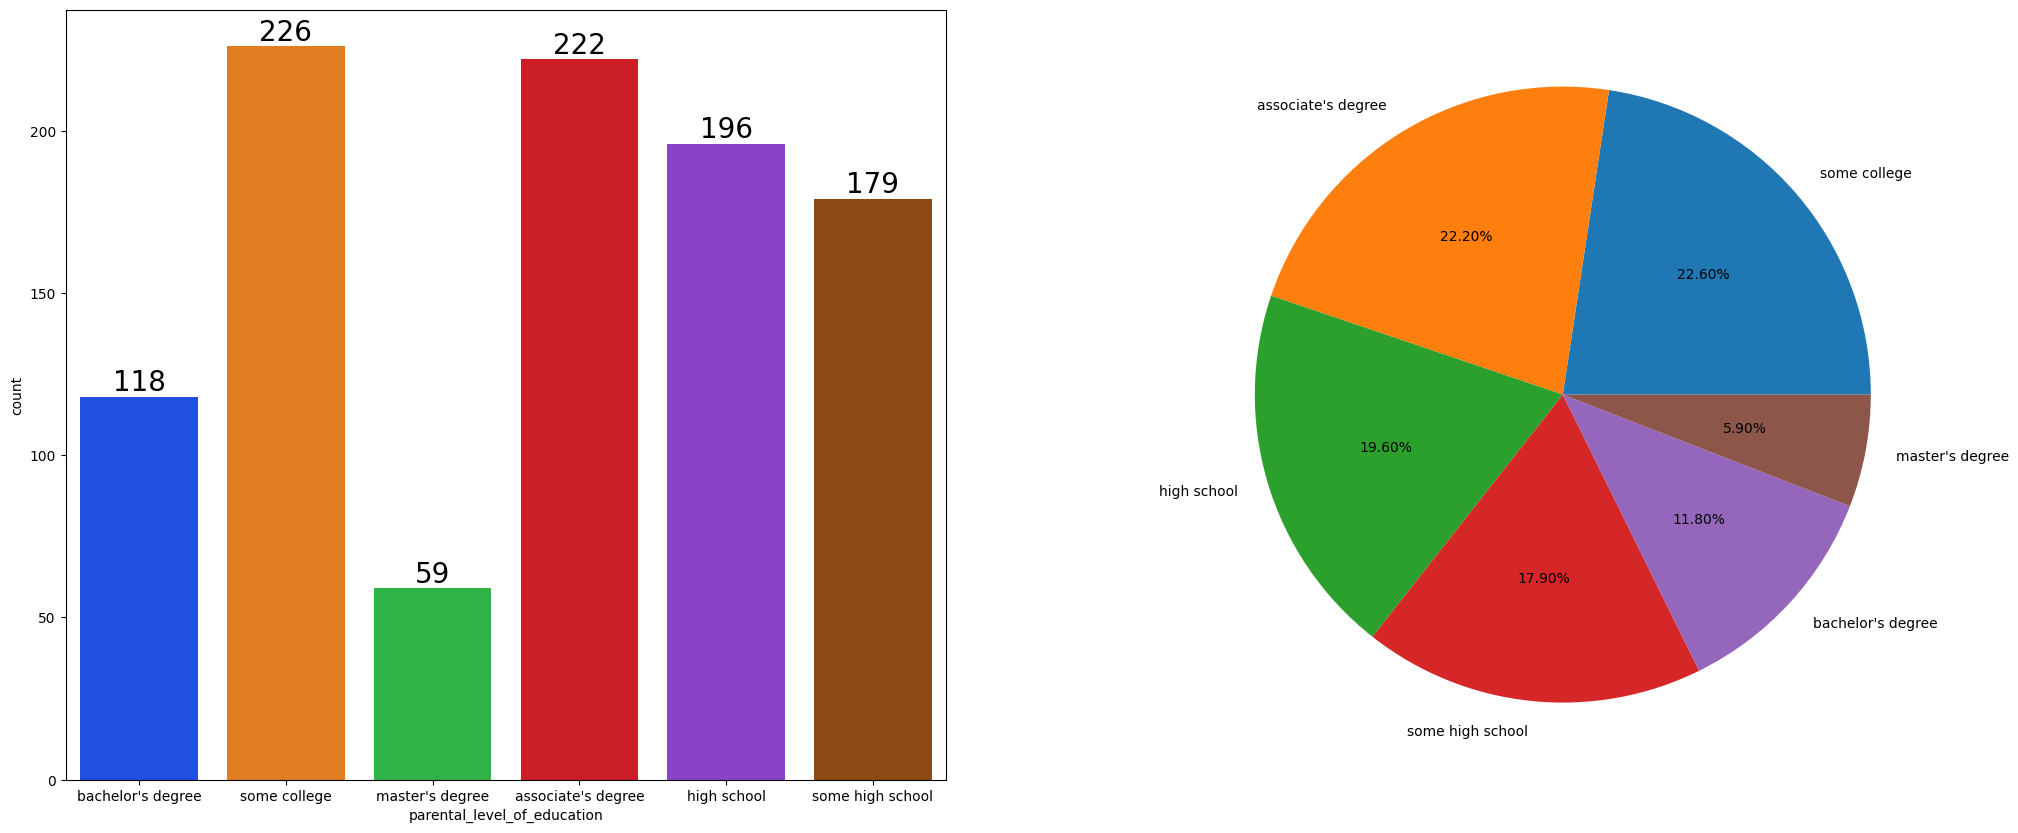

In [33]:
fig,ax=plt.subplots(1,2,figsize =(25,10))
sns.countplot(x='parental_level_of_education',data=df,ax=ax[0],palette='bright')
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)

plt.pie(df['parental_level_of_education'].value_counts(),labels=df['parental_level_of_education'].value_counts().index,autopct='%1.2f%%')
plt.show()

- Most parents have either degree from college or associate degree
- Very less parenets have a master degree almost 6%

#### Bivariate Analysis (Impact of parental education on scores)

In [34]:
df_parental=df.groupby('parental_level_of_education')[['total','reading_score','writing_score','math_score']].mean()

In [35]:
df_parental

,total,reading_score,writing_score,math_score
parental_level_of_education,,,,
associate's degree,208.707207,70.927928,69.896396,67.882883
bachelor's degree,215.771186,73.000000,73.381356,69.389831
high school,189.290816,64.704082,62.448980,62.137755
master's degree,220.796610,75.372881,75.677966,69.745763
some college,205.429204,69.460177,68.840708,67.128319
some high school,195.324022,66.938547,64.888268,63.497207


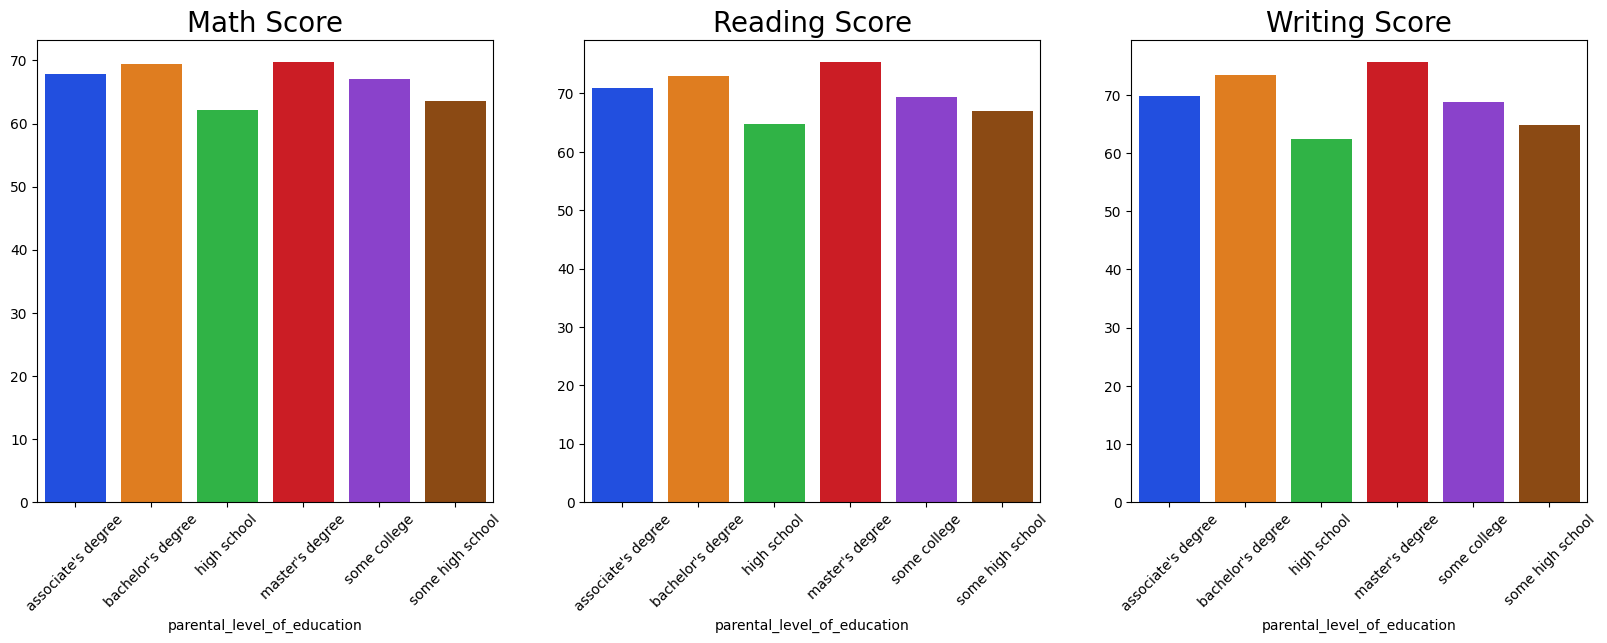

In [36]:
fig,ax=plt.subplots(1,3,figsize=(20,6))
sns.barplot(x=df_parental['math_score'].index,y=df_parental['math_score'].values,ax=ax[0],palette='bright')
ax[0].set_title('Math Score',color='black',size=20)
ax[0].tick_params(axis='x', rotation=45)


sns.barplot(x=df_parental['reading_score'].index,y=df_parental['reading_score'].values,ax=ax[1],palette='bright')
ax[1].set_title('Reading Score',color='black',size=20)
ax[1].tick_params(axis='x', rotation=45)

sns.barplot(x=df_parental['writing_score'].index,y=df_parental['writing_score'].values,ax=ax[2],palette='bright')
ax[2].set_title('Writing Score',color='black',size=20)
ax[2].tick_params(axis='x', rotation=45)

plt.show()


- The students whose parents have master degree are performing well in all 3 subjects

#### LUNCH Column

1. What type of lunch is common among students ?
2. Is Lunch has any effect on student's result ?

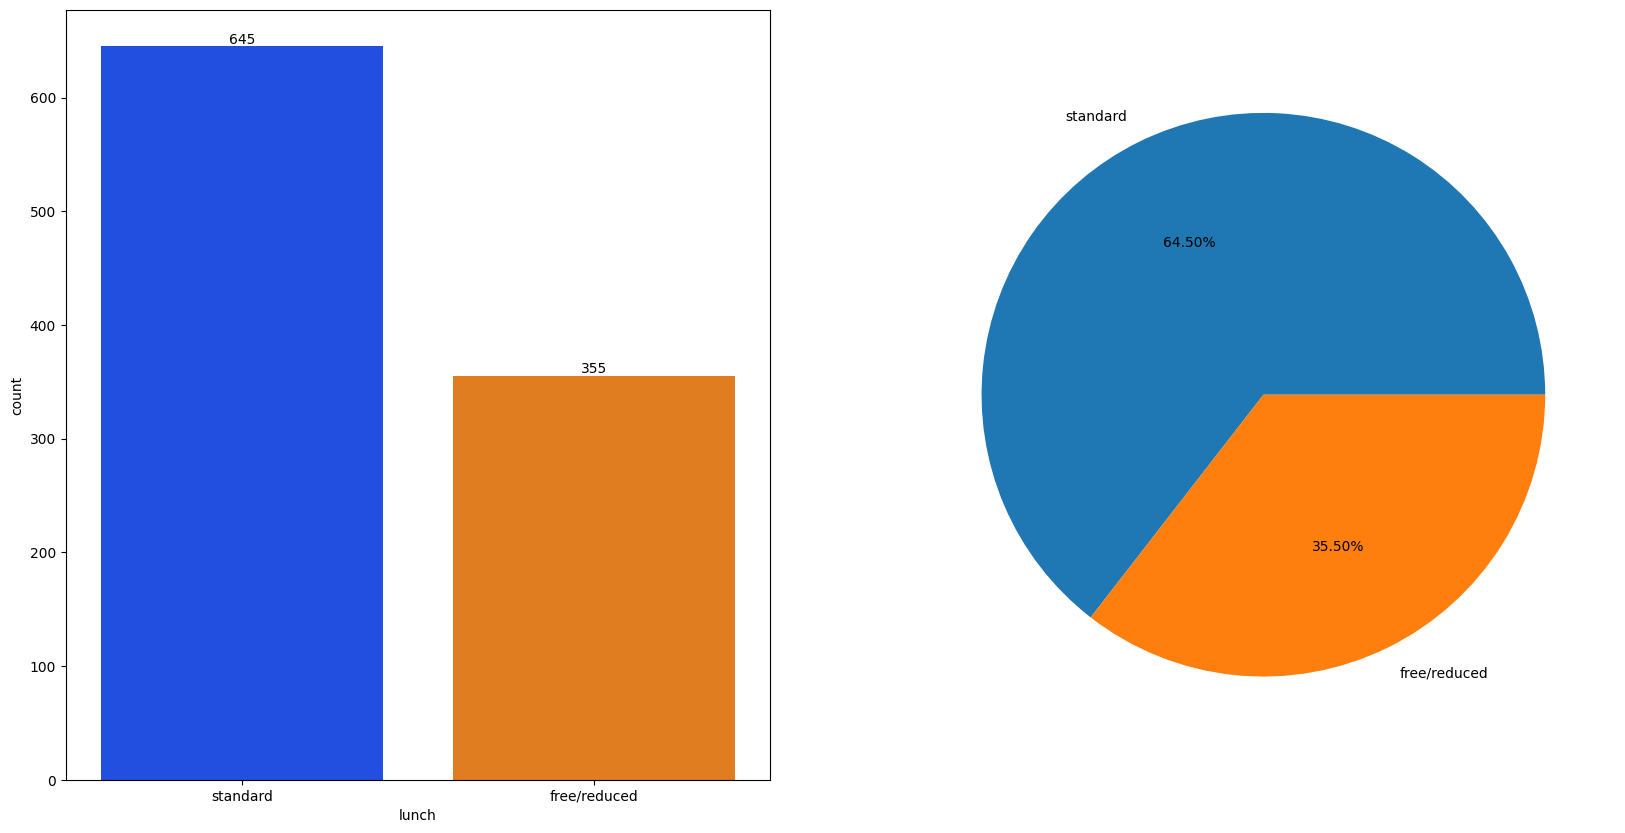

In [42]:
fig,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(data=df,x='lunch',ax=ax[0],palette='bright')
for container in ax[0].containers:
    ax[0].bar_label(container,size=10,color='black')

plt.pie(df['lunch'].value_counts(),labels=df['lunch'].value_counts().index,autopct='%1.2f%%')
plt.show()

- Almost 65% of student prefers standard lunch over free/reduced lunch

In [48]:
df_lunch=df.groupby('lunch')[['total','math_score','reading_score','writing_score']].mean()

Text(0.5, 1.0, 'Writing Score vs Lunch')

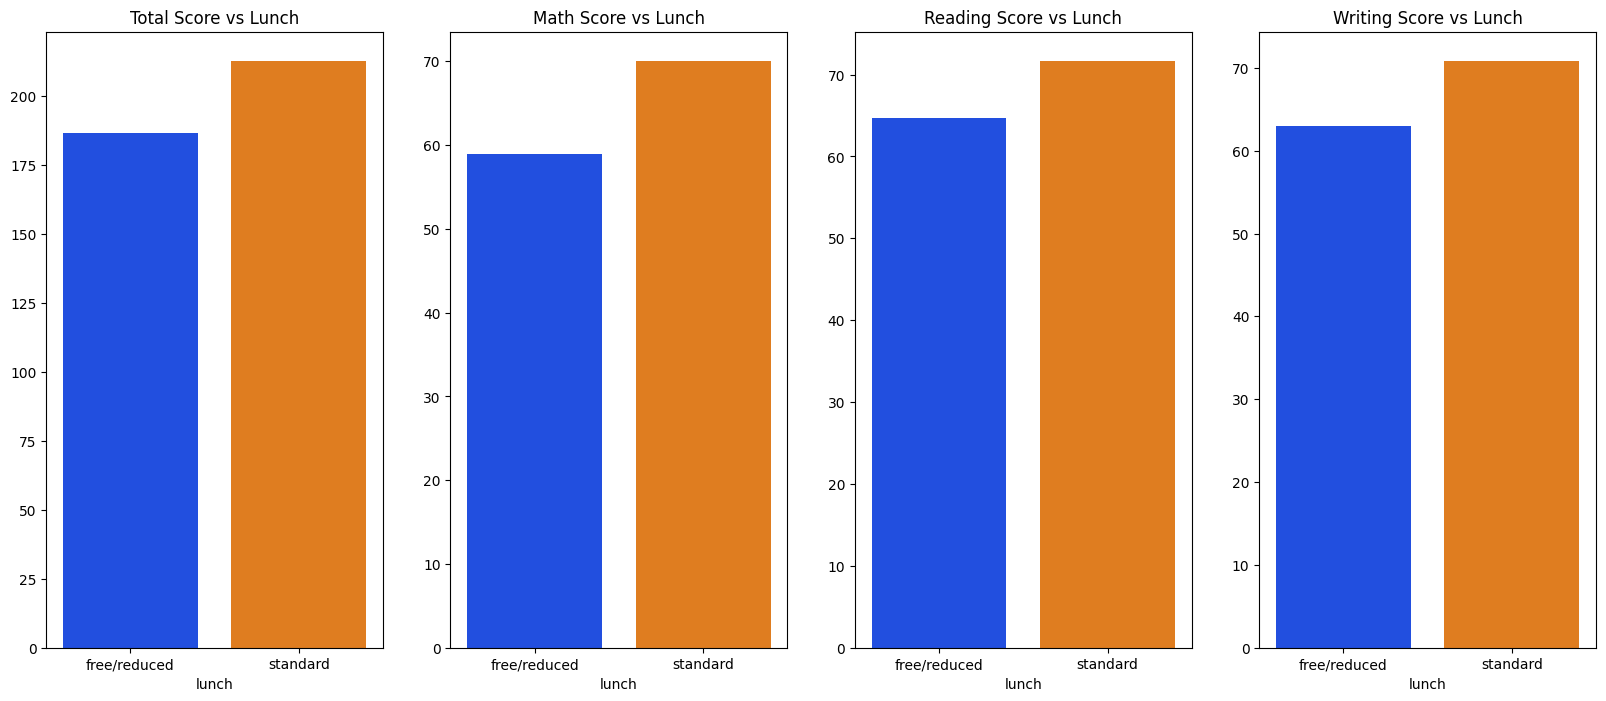

In [58]:
f,ax=plt.subplots(1,4,figsize=(20,8))
sns.barplot(x=df_lunch['total'].index,y=df_lunch['total'].values,ax=ax[0],palette='bright')
ax[0].set_title('Total Score vs Lunch')

sns.barplot(x=df_lunch['math_score'].index,y=df_lunch['math_score'].values,ax=ax[1],palette='bright')
ax[1].set_title('Math Score vs Lunch')

sns.barplot(x=df_lunch['reading_score'].index,y=df_lunch['reading_score'].values,ax=ax[2],palette='bright')
ax[2].set_title('Reading Score vs Lunch')

sns.barplot(x=df_lunch['writing_score'].index,y=df_lunch['writing_score'].values,ax=ax[3],palette='bright')
ax[3].set_title('Writing Score vs Lunch')



- Student having standard lunch are performing better in all 3 subjects

#### Test Prepration Course

1. Are student completing test prepration course ?
2. Has Test Prepration Score has any effect on Student's Performance

#### Univariate Analysis

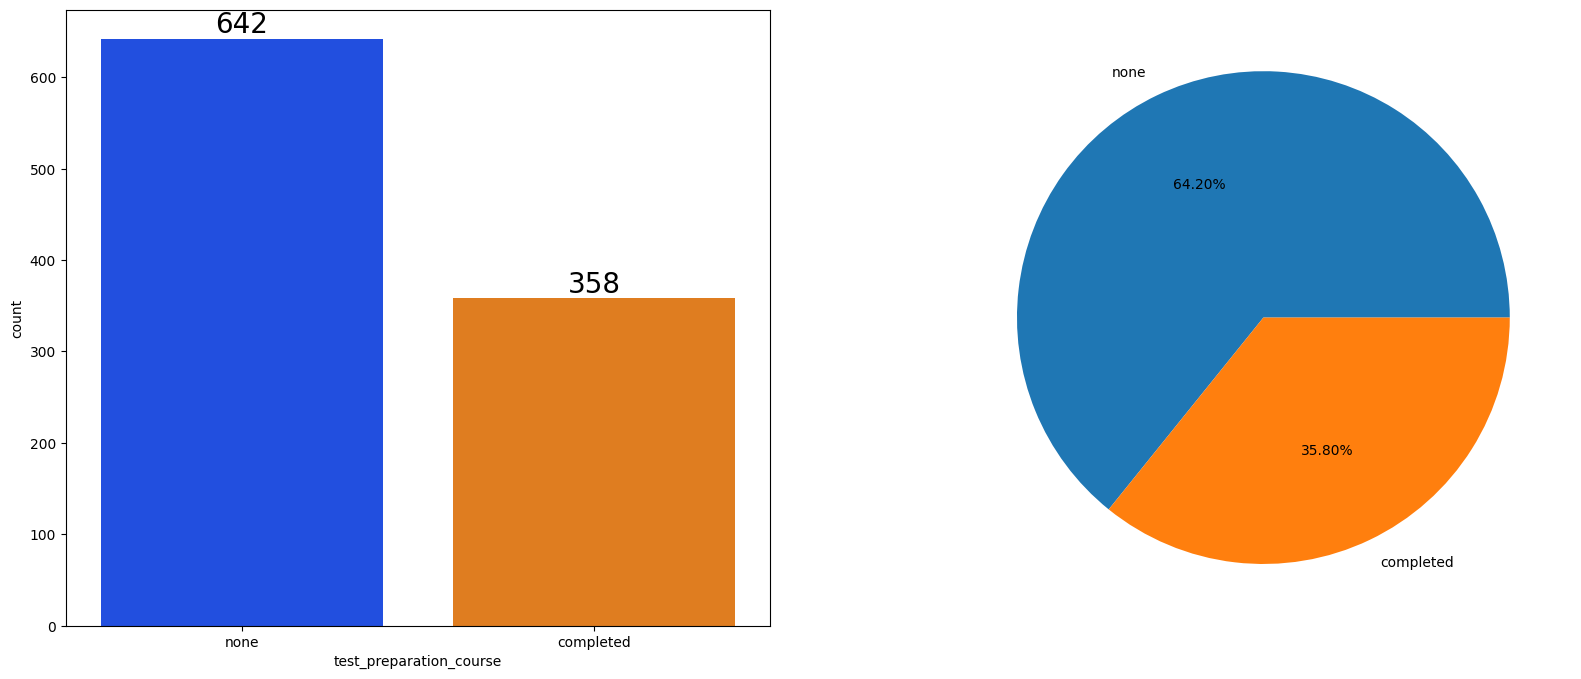

In [66]:
fig,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(data=df,x='test_preparation_course',ax=ax[0],palette='bright')
for container in ax[0].containers:
    ax[0].bar_label(container,size=20,color='black')

plt.pie(df['test_preparation_course'].value_counts(),labels=df['test_preparation_course'].value_counts().index,autopct='%1.2f%%')
plt.show()

- Almost 65% students has not completed the test prepration course

#### Bivariate Analysis

In [67]:
df_course=df.groupby('test_preparation_course')[['reading_score','math_score','writing_score']].mean()

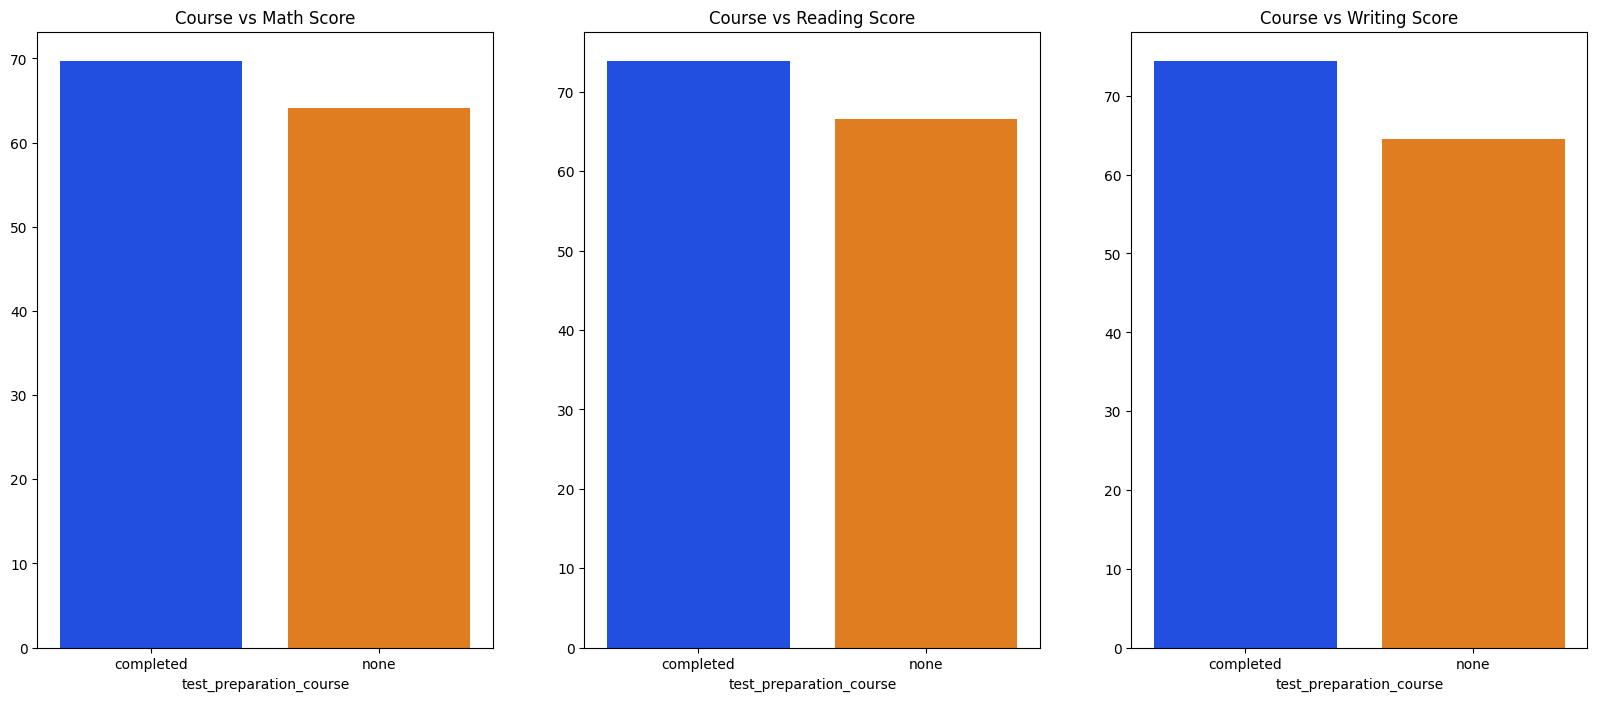

In [70]:
fig,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=df_course['math_score'].index,y=df_course['math_score'].values,ax=ax[0],palette='bright')
ax[0].set_title('Course vs Math Score')

sns.barplot(x=df_course['reading_score'].index,y=df_course['reading_score'].values,ax=ax[1],palette='bright')
ax[1].set_title('Course vs Reading Score')

sns.barplot(x=df_course['writing_score'].index,y=df_course['writing_score'].values,ax=ax[2],palette='bright')
ax[2].set_title('Course vs Writing Score')

plt.show()

- Student completed the test prepration course scores well 

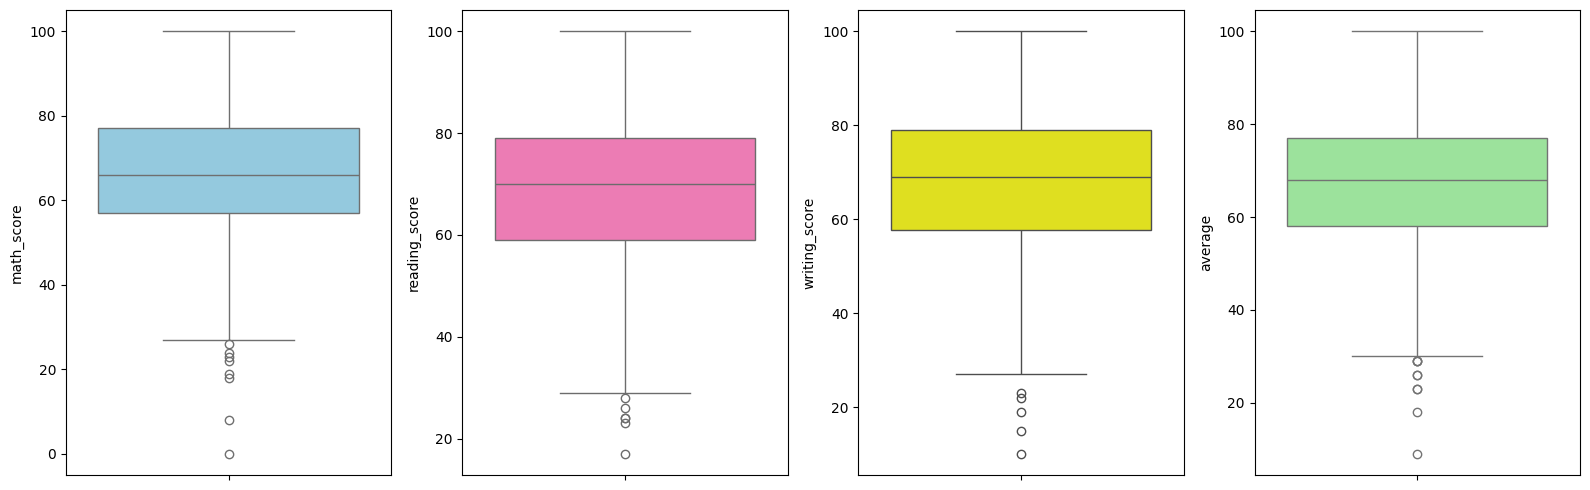

In [73]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average'],color='lightgreen')
plt.tight_layout()
plt.show()

- Each of them has some amount of outlier

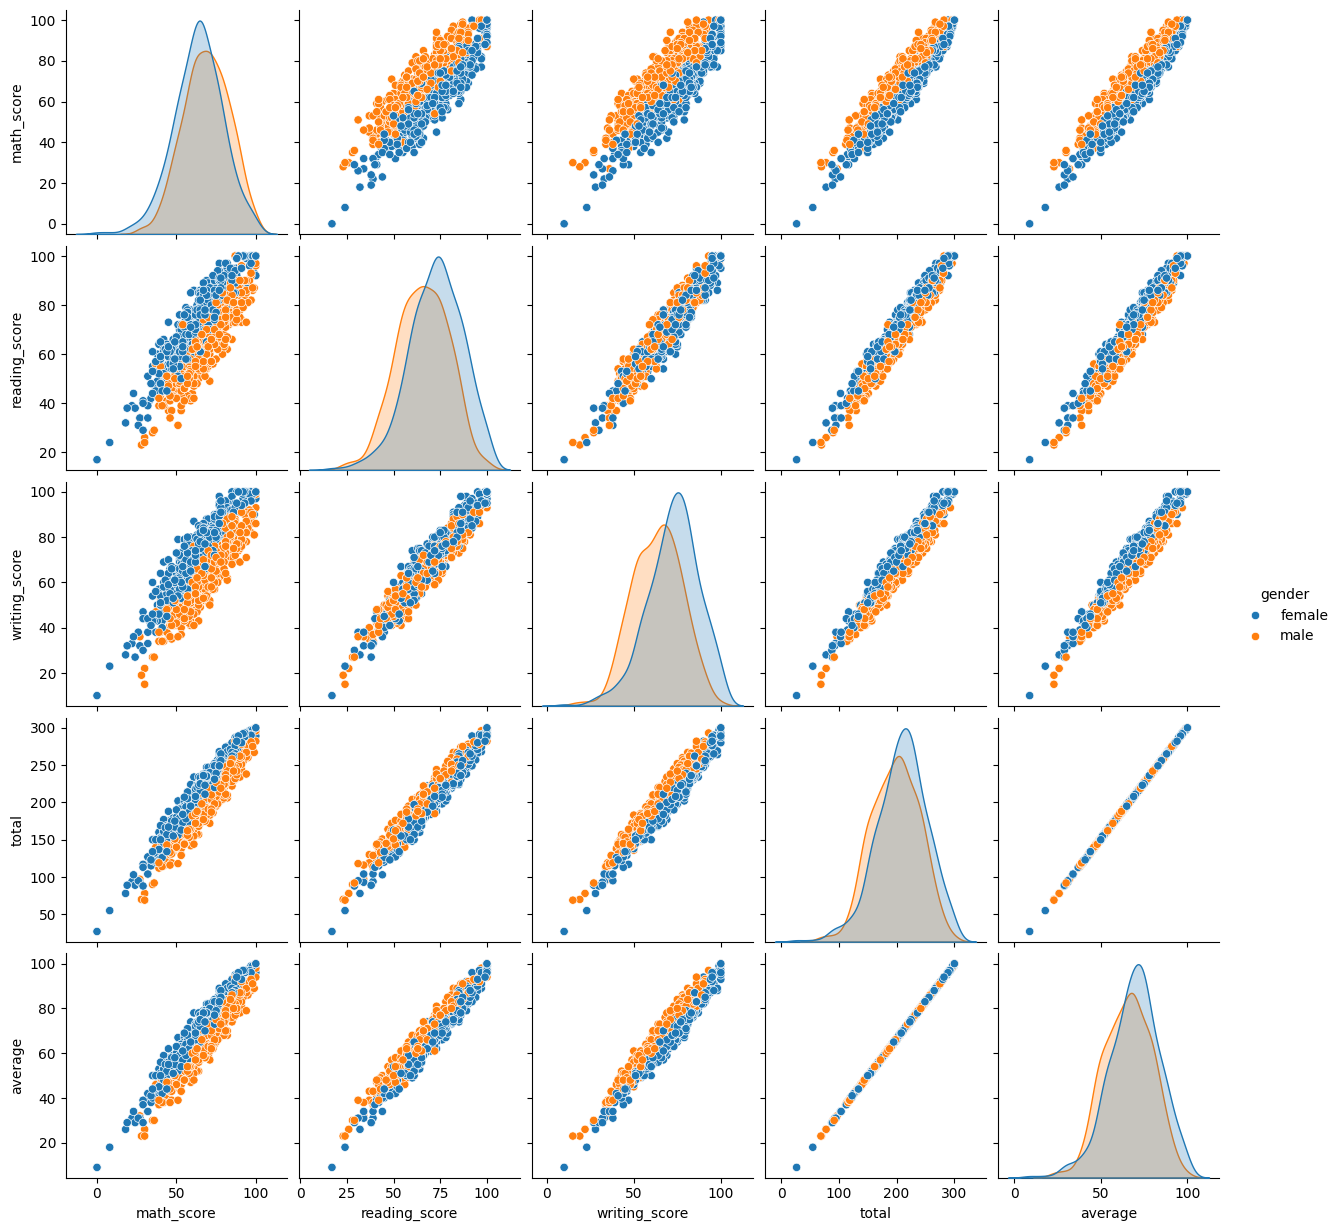

In [75]:
sns.pairplot(df,hue='gender')

- Every numerical value has linear relationship with other variables
- Eachof them are  normally distributed showcased by bell curve

### Conclusion